# [Data Understanding](https://rhindottire.github.io/Data-Mining/dataProcess.html#data-understanding)

This notebook explores the raw news corpus and records every finding that the
Data Preparation stage must act on. Nothing is cleaned or dropped here: every
anomaly is measured, shown with examples, and carried into the decision table
at the end of the page.

## 1. Collect Data

The corpus was collected with a crawl in the collection stage and stored at
`data/Web-Mining/crawling_detik.csv` with the required schema
(`id`, `isi_berita`, `label`, `url`). Crawling ethics and the robots.txt
decision for detik.com (`Allow: /`) are documented in
[Book 1](../book/book-1.ipynb); the standalone crawl script lives at
`scripts/run_crawl.py`.

This notebook loads the stored file and sends no request by default. The crawl
cells below document the collection code and only run when the file is missing
or `FORCE_CRAWL = True` is set: honest User-Agent, one-second delay between
requests, bounded volume, and an immediate stop when the site refuses access
with 403 or 429.

In [1]:
import re
from collections import Counter
from pathlib import Path

import langid
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from wordcloud import WordCloud

plt.style.use("seaborn-v0_8-whitegrid")

DATA_DIR = Path("..") / ".." / "data" / "Web-Mining"
df = pd.read_csv(DATA_DIR / "crawling_detik.csv")
df.head()

,id,isi_berita,label,url
0,1,Misi Indonesia untuk meloloskan tim 3x3 ke Oli...,sport,https://sport.detik.com/basket/d-8608204/perba...
1,2,Inilah daftar pelatih NBA terbaik sepanjang ma...,sport,https://sport.detik.com/basket/d-8296454/10-pe...
2,3,"Pelita Jaya mendapat dukungan ""tenaga"" baru un...",sport,https://sport.detik.com/basket/d-8353921/agar-...
3,4,Center Miami Heat Bam Adebayo mencetak 83 poin...,sport,https://sport.detik.com/basket/d-8395308/heat-...
4,5,Campus League 2026 Basketball Jakarta sudah me...,sport,https://sport.detik.com/basket/d-8512605/campu...


Sel ini memuat pustaka yang dipakai di seluruh halaman, lalu membaca berkas
CSV hasil crawl. Tidak ada permintaan jaringan di sini; `head()` menampilkan
isi mentah empat kolom sebagai titik awal sebelum perhitungan apa pun.

In [2]:
import time

import requests
import trafilatura

FORCE_CRAWL = False
POLITE_DELAY = 1.0
RETRY = 3
BACKOFF = [1, 2, 4]
CSV_PATH = DATA_DIR / "crawling_detik.csv"
HEADERS = {"User-Agent": "PPW Data-Mining course crawler (educational use)"}

pd.Series(
    {
        "csv_path": str(CSV_PATH),
        "file_present": CSV_PATH.exists(),
        "force_crawl": FORCE_CRAWL,
        "polite_delay_s": POLITE_DELAY,
    },
    name="config",
)

csv_path          ../../data/Web-Mining/crawling_detik.csv
file_present                                          True
force_crawl                                          False
polite_delay_s                                         1.0
Name: config, dtype: object

Konfigurasi koleksi dinyatakan di sini: `FORCE_CRAWL = False` membuat blok
crawl di bawah bersifat opsional, dan `CSV_PATH` mengarah ke berkas data yang
sudah ada. Keluaran sel ini adalah status konfigurasi pada saat build, bukan
hasil download.

In [3]:
def _get(url):
    r = requests.get(url, headers=HEADERS, timeout=30)
    if r.status_code in (403, 429):
        raise PermissionError(f"site refused {r.status_code} at {url}")
    r.raise_for_status()
    return r


def log(msg):
    print(msg, flush=True)


def get_urls_from_sitemap(sitemap_url):
    r = _get(sitemap_url)
    return re.findall(r"<loc>\s*<!\[CDATA\[\s*([^\]]+?)\s*\]\]>\s*</loc>", r.text)


def collect_article_urls(kanal, limit=100):
    base = f"https://{kanal}.detik.com"
    idx = _get(f"{base}/sitemap.xml")
    news_sitemaps = re.findall(r"https?://[^\s<\[]+?sitemap_news\.xml", idx.text)

    urls = set()
    for sm in news_sitemaps:
        try:
            for u in get_urls_from_sitemap(sm):
                urls.add(u)
        except requests.RequestException as e:
            log(f"  [skip sitemap] {sm} -> {e}")
        if len(urls) >= limit:
            break
        time.sleep(POLITE_DELAY)
    return list(urls)[:limit]


def crawl_article(url):
    for attempt in range(RETRY):
        try:
            downloaded = trafilatura.fetch_url(url)
            if downloaded:
                text = trafilatura.extract(downloaded, include_comments=False)
                if text:
                    return text
        except Exception as e:  # noqa: BLE001
            log(f"    [retry {attempt + 1}] {url} -> {str(e)[:60]}")
        if attempt < RETRY - 1:
            time.sleep(BACKOFF[attempt])
    return None


def crawl_many(urls, label):
    results = []
    ok = 0
    for i, url in enumerate(urls, start=1):
        isi = crawl_article(url)
        results.append({"url": url, "isi_berita": isi, "label": label})
        if isi:
            ok += 1
        if i % 10 == 0 or i == len(urls):
            log(f"  [{label}] {i}/{len(urls)} selesai (sukses={ok})")
        time.sleep(POLITE_DELAY)
    return results


print("Crawl functions defined — no network request has been sent yet.")

Crawl functions defined — no network request has been sent yet.


Sel ini mendefinisikan alur crawl yang sama dengan `scripts/run_crawl.py`:
URL artikel diambil dari sitemap resmi detik, isi artikel diekstrak dengan
trafilatura (komentar dibuang), semua request memakai User-Agent yang jujur,
jeda minimal satu detik, dan penolakan 403/429 menghentikan proses. Definisi
fungsi saja bukan permintaan jaringan.

In [4]:
if FORCE_CRAWL or not CSV_PATH.exists():
    log("Collecting URLs...")
    sport_urls = collect_article_urls("sport", limit=100)
    finance_urls = collect_article_urls("finance", limit=100)
    sport_rows = crawl_many(sport_urls, "sport")
    finance_rows = crawl_many(finance_urls, "finance")

    frames = pd.concat([pd.DataFrame(sport_rows), pd.DataFrame(finance_rows)], ignore_index=True)
    n_total = len(frames)
    n_fail = int(frames["isi_berita"].isna().sum())
    if n_fail == 0 and n_total == 200:
        frames = frames.dropna(subset=["isi_berita"]).reset_index(drop=True)
        frames.insert(0, "id", range(1, len(frames) + 1))
        frames = frames[["id", "isi_berita", "label", "url"]]
        frames.to_csv(CSV_PATH, index=False, encoding="utf-8")
        log(f"Re-crawl done: {n_total} articles saved to {CSV_PATH}.")
    else:
        log(f"{n_fail} articles failed — the stored file was NOT overwritten.")
else:
    print("Data already present — set FORCE_CRAWL = True to run a fresh crawl.")

Data already present — set FORCE_CRAWL = True to run a fresh crawl.


Inilah pintu eksekusinya: bila berkas belum ada atau `FORCE_CRAWL` disetel
`True`, proses crawl berjalan dan berkas baru ditulis hanya bila seluruh 200
artikel berhasil; bila ada kegagalan, keberatan situs, atau berkas sudah ada,
tidak ada permintaan jaringan dan berkas lama tidak disentuh. Nilai default
`False` memastikan build selalu memakai data yang sudah tersimpan.

## 2. Describe Data

Shape, types, class balance, missing values, and text-length statistics per label.

In [5]:
df.shape

(200, 4)

Ukuran kerja diperiksa lebih dulu: jumlah baris harus sama dengan jumlah
artikel hasil pengumpulan, dan kolomnya harus persis skema yang ditetapkan.

In [6]:
df.dtypes

id            int64
isi_berita      str
label           str
url             str
dtype: object

Tipe tiap kolom dilihat agar kolom teks benar-benar terbaca sebagai teks dan
kolom id sebagai bilangan bulat; kesalahan tipe di sini akan mengganggu semua
langkah berikutnya.

In [7]:
df["label"].value_counts()

label
sport      100
finance    100
Name: count, dtype: int64

Sebaran kelas dihitung per label untuk memastikan kedua kategori seimbang;
ketidakseimbangan akan membuat metrik evaluasi menyesatkan pada tahap nanti.

In [8]:
df.isna().sum()

id            0
isi_berita    0
label         0
url           0
dtype: int64

Pemeriksaan nilai kosong per kolom — artikel tanpa isi tidak bisa diproses,
jadi kekosongan apa pun harus ketahuan sebelum langkah lain berjalan.

In [9]:
df["n_chars"] = df["isi_berita"].str.len()
df["n_words"] = df["isi_berita"].str.split().str.len()
df.groupby("label")[["n_chars", "n_words"]].describe().round(1)

n_chars                                                           \
          count    mean     std     min     25%     50%     75%      max   
label                                                                      
finance   100.0  2828.0  1629.5  1210.0  1888.8  2501.0  3234.0  14106.0   
sport     100.0  2557.1   903.2   924.0  1992.0  2409.0  2886.0   5809.0   

        n_words                                                    
          count   mean    std    min    25%    50%    75%     max  
label                                                              
finance   100.0  379.9  216.4  161.0  263.5  315.5  425.2  1930.0  
sport     100.0  365.3  128.2  144.0  280.5  339.0  405.2   801.0

Panjang karakter dan kata diringkas per label (mean, quartil, min, maks).
Selisih antar label dan ekor kanan yang panjang menjadi dasar untuk memeriksa
outlier pada bagian verifikasi.

## 3. Explore Data

Representative excerpts, length visuals, word clouds, and raw token frequencies per label.

In [10]:
samples = {
    label: df.loc[df["label"] == label, "isi_berita"].iloc[0][:220]
    for label in sorted(df["label"].unique())
}
pd.Series(samples, name="article_excerpt")

finance    Direktorat Jenderal Pajak (DJP) menyampaikan s...
sport      Misi Indonesia untuk meloloskan tim 3x3 ke Oli...
Name: article_excerpt, dtype: str

Satu cuplikan artikel per label ditampilkan apa adanya — inilah wujud mentah
yang menentukan jenis kebisingan apa yang perlu dicacah pada bagian berikutnya.

### Visual overview

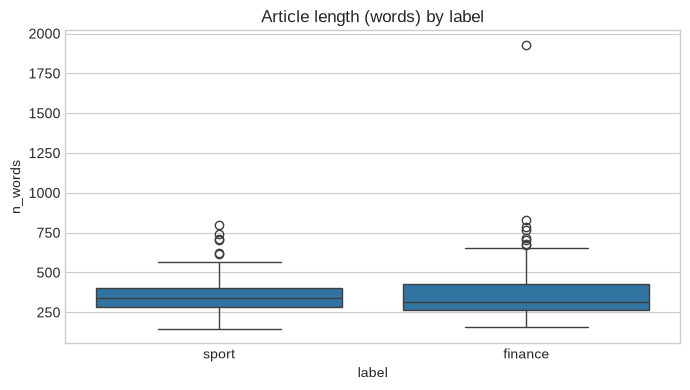

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df, x="label", y="n_words", ax=ax)
ax.set_title("Article length (words) by label")
fig.tight_layout()
plt.show()

Boxplot panjang kata per label memperlihatkan sebaran beserta titik ekornya;
titik di luar pagar menandai artikel yang jauh lebih panjang daripada
mayoritas dan perlu dicatat, bukan langsung dibuang.

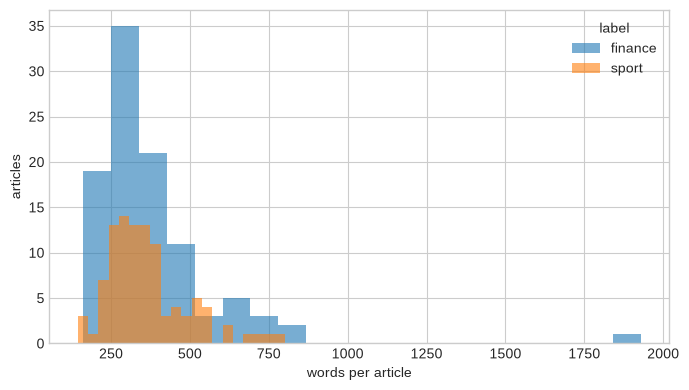

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
for label in sorted(df["label"].unique()):
    ax.hist(df.loc[df["label"] == label, "n_words"], bins=20, alpha=0.6, label=label)
ax.set_xlabel("words per article")
ax.set_ylabel("articles")
ax.legend(title="label")
fig.tight_layout()
plt.show()

Histogram panjang kata per label memperlihatkan bentuk sebarannya — simetris
atau miring ke kanan — sehingga rentang panjang yang wajar terlihat sekilas.

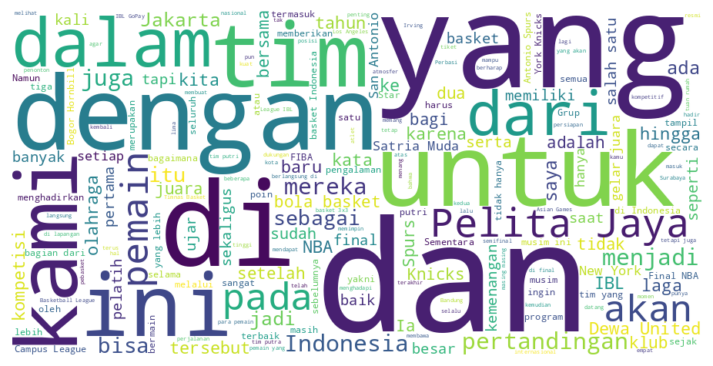

In [13]:
sport_text = " ".join(df.loc[df["label"] == "sport", "isi_berita"])
wc = WordCloud(width=900, height=450, background_color="white", random_state=42).generate(sport_text)
plt.figure(figsize=(9, 4.5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

Word cloud label sport menunjukkan kata yang paling sering muncul secara kasar
tanpa normalisasi apa pun, sebagai gambaran isi kategori tersebut.

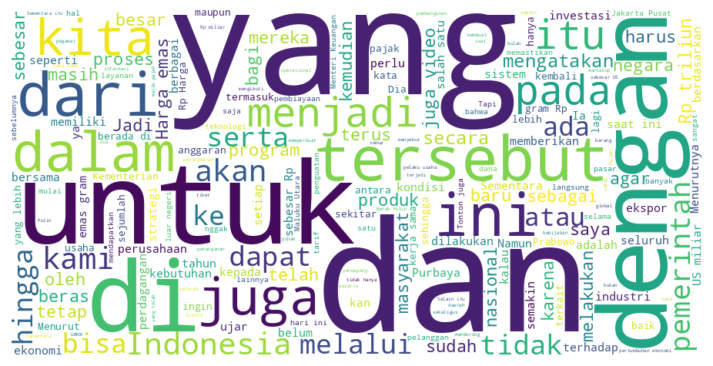

In [14]:
finance_text = " ".join(df.loc[df["label"] == "finance", "isi_berita"])
wc = WordCloud(width=900, height=450, background_color="white", random_state=42).generate(finance_text)
plt.figure(figsize=(9, 4.5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

Word cloud label finance melakukan hal yang sama untuk kategori tersebut;
perbedaan kosakata antar kedua awan menjadi indikasi awal bahwa kelas mudah
dibedakan model.

### Top Tokens

In [15]:
def naive_tokens(series):
    text = " ".join(series).lower()
    return [t for t in re.findall(r"[a-z]+", text) if len(t) > 2]


top = {}
for label in sorted(df["label"].unique()):
    top[label] = Counter(naive_tokens(df.loc[df["label"] == label, "isi_berita"])).most_common(12)

pd.DataFrame({label: pd.Series(dict(pairs)) for label, pairs in top.items()})

,finance,sport
basket,NaN,253.0
dalam,318.0,255.0
dan,779.0,753.0
dari,309.0,309.0
dengan,382.0,406.0
indonesia,220.0,234.0
ini,324.0,415.0
itu,215.0,NaN
juga,290.0,NaN
kami,NaN,239.0


Frekuensi token naive (huruf saja, tanpa normalisasi) dibandingkan antar label
dalam satu tabel — kata berimbuh mendominasi kedua kolom, sementara istilah
domain memisahkan label. Tabel ini menjadi bukti dasar keputusan stopword dan
alasan mengapa istilah domain justru harus dipertahankan.

## 4. Verify Data Quality

Structural integrity: duplicates, identifier continuity, label consistency, and length outliers.

In [16]:
checks = pd.Series(
    {
        "exact duplicate rows": int(df.duplicated().sum()),
        "duplicate urls": int(df["url"].duplicated().sum()),
        "missing cells": int(df.isna().sum().sum()),
        "empty articles": int((df["isi_berita"].str.strip() == "").sum()),
        "id sequential 1..n": df["id"].tolist() == list(range(1, len(df) + 1)),
    },
    name="value",
)
checks

exact duplicate rows       0
duplicate urls             0
missing cells              0
empty articles             0
id sequential 1..n      True
Name: value, dtype: object

Pemeriksaan integritas struktur: baris ganda, URL ganda, nilai kosong,
artikel kosong, dan kelengkapan urutan id. Semua harus bersih supaya data
dianggap layak masuk tahap persiapan.

In [17]:
host = df["url"].str.extract(r"https?://([a-z]+)\.detik\.com")[0]
host_check = pd.Series(
    {
        "rows with parsed host": int(host.notna().sum()),
        "host matches label": int((host == df["label"]).sum()),
        "mismatches": int((host != df["label"]).sum()),
    },
    name="value",
)
host_check

rows with parsed host    200
host matches label       200
mismatches                 0
Name: value, dtype: int64

Hostname URL diekstrak lalu dibandingkan dengan kolom label — kalau semua
cocok, label bisa dipercaya tanpa verifikasi manual per baris.

In [18]:
q1, q3 = df["n_words"].quantile([0.25, 0.75])
iqr = q3 - q1
low_fence, high_fence = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outlier_mask = (df["n_words"] < low_fence) | (df["n_words"] > high_fence)
pd.Series(
    {
        "fence_low_words": round(low_fence, 1),
        "fence_high_words": round(high_fence, 1),
        "outlier_rows": int(outlier_mask.sum()),
    },
    name="value",
)

fence_low_words      36.0
fence_high_words    654.0
outlier_rows         12.0
Name: value, dtype: float64

Pagar IQR dihitung dari panjang kata; jumlah artikel di luar pagar dicatat
sebagai temuan. Nilai ekstrem di sini justru informatif untuk evaluasi nanti,
bukan alasan membuang baris.

In [19]:
df.loc[outlier_mask, ["id", "label", "n_words"]].sort_values("n_words")

,id,label,n_words
168,169,finance,674
142,143,finance,682
31,32,sport,702
118,119,finance,705
1,2,sport,710
174,175,finance,717
72,73,sport,739
180,181,finance,766
145,146,finance,786
68,69,sport,801


Daftar baris outlier ditampilkan lengkap dengan id dan labelnya supaya
keputusan mempertahankan baris-baris ini bisa dirujuk secara konkret di tahap
persiapan dan evaluasi.

## 5. Text Noise Census

Every anomaly class that Data Preparation may need to act on, with counts and
examples drawn from the corpus.

### Artifact Census

In [20]:
def first_match(text, pattern):
    m = re.search(pattern, text)
    if not m:
        return "-"
    frag = m.group(0).replace("\n", " ").strip()
    if not frag:
        frag = text[max(0, m.start() - 30): m.end() + 30].replace("\n", " ")
    return " ".join(frag.split())[:70]


patterns = {
    "line breaks": r"\n",
    "space runs (2+)": r" {2,}",
    "pipe table rows": r"\|[^|\n]*\|",
    "markdown bullets": r"(?m)^\s*[-*]\s",
    "markdown headings": r"(?m)^#{1,6}\s",
    "html tags": r"<[^>]+>",
    "html entities": r"&[a-z]+;|&#\d+;",
    "embedded urls": r"https?://\S+|www\.\S+",
    "email addresses": r"[\w.+-]+@[\w-]+\.[\w.]+",
    "mention handles": r"@\w+",
    "punctuation runs (3+)": r"[!?]{3,}|\.{4,}",
}

artifact_rows = []
for name, pattern in patterns.items():
    hit = df["isi_berita"].str.contains(pattern, regex=True, na=False)
    artifact_rows.append(
        {
            "artifact": name,
            "docs_affected": int(hit.sum()),
            "first_match": first_match(df.loc[hit, "isi_berita"].iloc[0], pattern)
            if hit.any()
            else "-",
        }
    )
pd.DataFrame(artifact_rows)

,artifact,docs_affected,first_match
0,line breaks,200,gensi 3x3 yang dipercaya FIBA. Kerja sama itu ...
1,space runs (2+),1,ian dalam kegiatan tersebut. | Foto: Dok. Andi...
2,pipe table rows,37,| Baca juga: Sejarah Bola Basket: Dari YMCA ke...
3,markdown bullets,15,*
4,markdown headings,1,###
5,html tags,0,-
6,html entities,0,-
7,embedded urls,2,https://siskop2mi.bp2mi.go.id.
8,email addresses,0,-
9,mention handles,4,@memgrizz


Sebelas pola artefak format dicacah pada level dokumen: pemisah baris,
spasi beruntun, sisa tabel dan daftar markdown, tautan, surel, mention, dan
tanda baca beruntun. Kolom `first_match` mengambil satu contoh nyata dari
korpus untuk tiap pola supaya hitungannya bisa diverifikasi mata.

In [21]:
naive_text = " ".join(df["isi_berita"]).lower()
naive_all_tokens = re.findall(r"[a-z]+", naive_text)
single_char = (
    pd.Series([t for t in naive_all_tokens if len(t) == 1])
    .value_counts()
    .rename_axis("token")
    .rename("count")
    .to_frame()
    .head(15)
)
single_char

,count
token,
x,89
u,64
i,39
s,34
b,32
a,27
d,22
e,17
y,16


Token satu huruf dihitung setelah pembersihan naive; sebagian besar adalah
sisa pemisahan seperti kata berangka yang terpotong. Hitungannya dicatat dulu
sebagai bukti sebelum keputusan membuang token pendek diambil.

In [22]:
short_tokens = (
    pd.Series([t for t in naive_all_tokens if len(t) <= 2])
    .value_counts()
    .rename_axis("token")
    .rename("count")
    .to_frame()
    .head(20)
)
short_tokens

,count
token,
di,1436
rp,285
ke,260
ia,133
x,89
us,75
u,64
ya,52
of,46


Token dua huruf atau kurang didaftarkan beserta frekuensinya. Daftar ini
berisi campuran kata berimbuh nyata dan sisa artefak, sehingga keputusannya
harus per token — bukan memotong semua token pendek sekaligus.

In [23]:
elong_words = [
    w for w in re.findall(r"\b[a-zA-Z']+\b", naive_text) if re.search(r"(.)\1{2,}", w)
]
elong_table = (
    pd.Series(elong_words)
    .value_counts()
    .rename_axis("token")
    .rename("count")
    .to_frame()
    .head(15)
)
elong_table

,count
token,
iii,14
ppp,3
xiii,2
viii,1
sss,1
kkks,1


Kata dengan huruf berulang dicari lewat pola balikan `(.)\1{2,}`. Yang muncul
di sini kebanyakan angka Romawi dan akronim, bukan elongasi informal gaya
obrolan — temuan ini menentukan apakah normalisasi lipatan kata diperlukan.

In [24]:
allcaps = re.findall(r"\b[A-Z]{3,}\b", " ".join(df["isi_berita"]))
allcaps_table = (
    pd.Series(allcaps)
    .value_counts()
    .rename_axis("acronym")
    .rename("count")
    .to_frame()
    .head(15)
)
allcaps_table

,count
acronym,
IBL,164
NBA,151
FIBA,69
UMKM,59
WIB,48
DPR,48
BPS,36
MVP,35
MBG,34


Token huruf besar minimal tiga huruf dicacah — mayoritas adalah akronim
olahraga dan nama lembaga yang merupakan entitas nyata, sehingga kelas ini
dipertahankan, bukan dibersihkan.

### Character Inventory

In [25]:
from collections import Counter, defaultdict

glyph_counts = Counter()
glyph_docs = Counter()
glyph_labels = defaultdict(set)
for _, r in df.iterrows():
    glyph_counts.update(c for c in r["isi_berita"] if ord(c) > 127)
    for c in {ch for ch in r["isi_berita"] if ord(ch) > 127}:
        glyph_docs[c] += 1
        glyph_labels[c].add(r["label"])

order = sorted(glyph_docs, key=lambda k: -glyph_docs[k])
pd.DataFrame(
    {
        "glyph": order,
        "codepoint": [f"U+{ord(c):04X}" for c in order],
        "count": [glyph_counts[c] for c in order],
        "docs": [glyph_docs[c] for c in order],
        "label": ["/".join(sorted(glyph_labels[c])) for c in order],
    }
)

,glyph,codepoint,count,docs,label
0,é,U+00E9,3,2,finance/sport
1,—,U+2014,1,1,sport
2,…,U+2026,1,1,sport
3,í,U+00ED,1,1,sport
4,‑,U+2011,1,1,sport
5,➡,U+27A1,1,1,sport
6,️,U+FE0F,1,1,sport
7,📺,U+1F4FA,1,1,sport


Semua karakter di luar ASCII dicacah lintas korpus: berapa banyak glyph
berbeda, berapa total kemunculan, di berapa dokumen, dan pada label mana.
Kolom `codepoint` membantu kelas glyph (aksen, tanda hubung, emoji, simbol).
Ini melengkapi celah yang belum diukur sebelumnya.

In [26]:
import unicodedata


def nfd(text):
    return "".join(
        c for c in unicodedata.normalize("NFD", text) if not unicodedata.combining(c)
    ).replace("\u2011", "-").replace("\u2010", "-")


rows = []
for _, r in df.iterrows():
    if not any(ord(c) > 127 for c in r["isi_berita"]):
        continue
    t = r["isi_berita"]
    i = next(k for k, ch in enumerate(t) if ord(ch) > 127)
    seg = t[max(0, i - 24): i + 24]
    rows.append(
        {"id": r["id"], "before": " ".join(seg.split()), "after_nfd": " ".join(nfd(seg).split())}
    )
pd.DataFrame(rows).set_index("id")

,before,after_nfd
id,,
19,a overdosis atau tidak. — Memphis Grizzlies (@me,a overdosis atau tidak. — Memphis Grizzlies (@me
57,"atih Dewa United, Augustí Julbe, menerima techni","atih Dewa United, Augusti Julbe, menerima techni"
66,hensif berbasis evidence‑based medicine agar keb,hensif berbasis evidence-based medicine agar keb
89,gan 11 poin. LUKE BLOCK ➡️ STEPH BUCKET! 📺@NBAon,gan 11 poin. LUKE BLOCK ➡️ STEPH BUCKET! 📺@NBAon
91,"y Business Unit PT Nestlé Indonesia, Alaa Shaaba","y Business Unit PT Nestle Indonesia, Alaa Shaaba"
181,"(Hotel, Restaurant, Café, dan Bakery) dengan su","(Hotel, Restaurant, Cafe, dan Bakery) dengan su"


Dekomposisi NFD menanggalkan tanda gabung (aksen `é`/`í` menjadi huruf
polosnya) dan menormalkan tanda hubung non-standar menjadi `-`. Tabel
sebelum/sesudah menunjukkan efek pada dokumen yang terdampak; aksen yang
tersisa diubah saat pembersihan tahap awal.

### Number Artifacts

In [27]:
digit_docs = int(df["isi_berita"].str.contains(r"\d", regex=True).sum())
digit_frags = re.findall(r"\S*\d\S*", " ".join(df["isi_berita"]))
pd.Series(
    {
        "docs containing digits": digit_docs,
        "digit fragments": len(digit_frags),
        "unique digit fragments": len(set(digit_frags)),
    },
    name="value",
)

docs containing digits     200
digit fragments           3279
unique digit fragments    1407
Name: value, dtype: int64

Dokumen yang memuat angka dihitung bersama jumlah fragmennya. Angka dalam
berita — skor, tanggal, harga — menentukan apakah tahap persiapan boleh
membuang digit begitu saja atau harus menjaga bentuk tertentu tetap utuh.

In [28]:
frag = Counter(digit_frags)
pd.DataFrame(frag.most_common(15), columns=["fragment", "count"])

,fragment,count
0,2026,250
1,2026.,135
2,3x3,70
3,"2026,",56
4,1,50
5,5,42
6,(3/9/2026).,36
7,3,34
8,2025,32
9,10,32


Fragmen yang memuat angka didaftarkan beserta frekuensinya. Komposit seperti
skor pertandingan dan potongan tanggal terlihat di sini sebagai satu fragmen
utuh — bentuk seperti ini yang nanti dilindungi sebelum simbolnya dibuang.

### Stopword Share

In [29]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

STOPWORDS = set(StopWordRemoverFactory().create_stop_word_remover().get_dictionary().words)
sw_hits = [t for t in naive_all_tokens if t in STOPWORDS]
pd.Series(
    {
        "stopword list entries": len(STOPWORDS),
        "naive tokens matched": len(sw_hits),
        "share of naive tokens %": round(100 * len(sw_hits) / len(naive_all_tokens), 1),
    },
    name="value",
)

stopword list entries        123.0
naive tokens matched       16899.0
share of naive tokens %       23.4
Name: value, dtype: float64

Daftar stopword Sastrawi dicocokkan terhadap seluruh token naive. Persentase
yang tertandingi menjadi ukuran berapa banyak kosakata yang akan hilang
seandainya penghapusan stopword dijalankan pada tahap persiapan.

### Slang Candidates

In [30]:
from indoNLP.preprocessing import replace_slang


def is_capital_mid(text, pos):
    if pos == 0:
        return False
    prev = text[max(0, pos - 2):pos]
    return text[pos].isupper() and not re.search(r"[.!?]\s$", prev)


slang_hit, slang_cap_mid = Counter(), Counter()
for text in df["isi_berita"]:
    for m in re.finditer(r"[A-Za-z]+", text):
        w = m.group(0).lower()
        if replace_slang(w) != w:
            slang_hit[w] += 1
            if is_capital_mid(text, m.start()):
                slang_cap_mid[w] += 1
pd.Series(
    {
        "dictionary tokens hit": len(slang_hit),
        "occurrences": sum(slang_hit.values()),
        "occurrences capital mid-sentence": sum(slang_cap_mid.values()),
    },
    name="value",
)

dictionary tokens hit                76
occurrences                         563
occurrences capital mid-sentence    306
Name: value, dtype: int64

Kamus indoNLP (`replace_slang`) dijalankan pada tiap token kata. Hitungannya
menunjukkan berapa banyak token yang akan berubah bila terjemahan slang
diterapkan tanpa penyaringan, dan berapa di antaranya justru muncul kapital
di tengah kalimat — kemungkinan nama yang tidak boleh disentuh.

In [31]:
pd.DataFrame(
    [
        {
            "token": w,
            "occurrences": n,
            "capital_mid": slang_cap_mid.get(w, 0),
            "dictionary_mapping": replace_slang(w),
        }
        for w, n in slang_hit.most_common(15)
    ]
)

,token,occurrences,capital_mid,dictionary_mapping
0,x,89,1,kali
1,u,64,64,lu
2,nggak,36,2,enggak
3,s,34,4,si
4,mbg,34,34,mbak
5,sma,26,21,sama
6,d,22,20,di
7,gt,20,20,begitu
8,y,16,13,ya
9,pass,13,13,pas


Kandidat slang teratas beserta padanan kamusnya. Kolom `capital_mid`
menandai kandidat yang bisa jadi nama atau istilah, sehingga wajib lolos
pemeriksaan konteks per token sebelum diterjemahkan.

### Language Census

In [32]:
sentence_langs = Counter()
foreign_examples = []
for text in df["isi_berita"]:
    for sent in re.split(r"(?<=[.!?])\s+", text):
        sent = sent.strip()
        if len(sent.split()) < 4:
            continue
        lang, _ = langid.classify(sent)
        sentence_langs[lang] += 1
        if lang not in ("id", "ms") and len(foreign_examples) < 12:
            foreign_examples.append({"lang": lang, "sentence": sent[:120]})
pd.Series(sentence_langs, name="sentences").sort_values(ascending=False)

id    3665
ms     539
en      41
jv      13
es      11
de       8
rw       4
sv       3
tl       3
pt       3
et       3
eu       3
zh       2
eo       2
ro       2
sw       2
af       1
no       1
it       1
da       1
fr       1
zu       1
ca       1
la       1
cy       1
lv       1
lt       1
xh       1
Name: sentences, dtype: int64

Tiap kalimat berminimal empat kata diklasifikasi bahasanya dengan langid;
hasilnya disimpan di `sentence_langs` sebagai bukti sebaran bahasa korpus.

In [33]:
pd.DataFrame(foreign_examples, columns=["lang", "sentence"])

,lang,sentence
0,en,"Semasa kariernya, Brown memimpin Denver Nugget..."
1,en,83 POINTS FOR BAM ADEBAYO.
2,rw,"Keren,"" ujar ujar guard Minnesota Timberwolves..."
3,en,| Wilt Chamberlain | 100 | 1962-03-02 | PHW | ...
4,en,| Bam Adebayo | 83 | 2026-03-10 | MIA | \n| 3.
5,en,| Kobe Bryant | 81 | 2006-01-22 | LAL | \n| 4.
6,en,| Wilt Chamberlain | 78 | 1961-12-08 | PHW | \...
7,sv,| David Thompson | 73 | 1978-04-09 | DEN | \n| 7.
8,en,| Wilt Chamberlain | 73 | 1962-11-16 | SFW | \...
9,en,| Wilt Chamberlain | 73 | 1962-01-13 | PHW | \...


Contoh kalimat berlabel bahasa asing ditampilkan apa adanya — dari sinilah
terlihat apakah yang berlabel asing benar-benar tulisan asing atau hanya
baris tabel daftar pemain yang keliru diklasifikasi.

In [34]:
vocab = Counter(re.findall(r"[a-z]{4,}", naive_text))
token_candidates = []
for tok, freq in vocab.most_common(400):
    lang, _ = langid.classify(tok)
    if lang == "en":
        token_candidates.append({"token": tok, "freq": freq})
pd.DataFrame(token_candidates[:20])

,token,freq
0,dalam,573
1,juga,509
2,pada,474
3,akan,368
4,tersebut,345
5,kami,330
6,jakarta,276
7,pemain,273
8,basket,253
9,kita,249


Empat ratus token teratas diklasifikasi per token; label `en` yang menempel
pada kata Indonesia murni membuktikan klasifikasi per token tidak bisa dipakai
untuk memutuskan terjemahan — keputusan bahasa harus dari makna, bukan label.

### Name Collisions

In [35]:
lower_docs, cap_mid_docs = Counter(), Counter()
for text in df["isi_berita"]:
    lower_docs.update({w.lower() for w in re.findall(r"\b[a-z]{3,}\b", text)})
    cap_mid_docs.update(
        {w.lower() for w in re.findall(r"(?<![.!?]\s)\b[A-Z][a-z]{2,}\b", text)}
    )
mixed_all = [
    (w, cap_mid_docs[w], lower_docs.get(w, 0))
    for w in cap_mid_docs
    if cap_mid_docs[w] >= 2
]
mixed_candidates = pd.DataFrame(
    sorted(mixed_all, key=lambda r: -r[1]),
    columns=["token", "docs_capitalized_mid", "docs_lowercase"],
).head(15)
mixed_candidates

,token,docs_capitalized_mid,docs_lowercase
0,indonesia,130,0
1,jakarta,108,0
2,kamis,53,0
3,basketball,49,4
4,kami,47,76
5,menteri,46,1
6,selasa,44,0
7,pusat,39,9
8,pelita,38,1
9,league,38,0


Kandidat nama dicari dari token yang kapital di tengah kalimat pada minimal
dua dokumen. Saringan posisi tengah kalimat membuang kata umum yang hanya
kapital di awal kalimat, sehingga yang tersisa didominasi nama dan istilah.

In [36]:
context_rows = []
for tok in mixed_candidates["token"].head(5):
    for text in df["isi_berita"]:
        m = re.search(rf".{{0,50}}\b{re.escape(tok)}\b.{{0,50}}", text, re.IGNORECASE)
        if m:
            context_rows.append({"token": tok, "context": m.group(0).replace("\n", " ")})
            break
pd.DataFrame(context_rows, columns=["token", "context"])

,token,context
0,indonesia,Misi Indonesia untuk meloloskan tim 3x3 ke Oli...
1,jakarta,Salah satunya adalah Bank Jakarta yang baru sa...
2,kamis,Kerjasama itu diumumkan secara resmi di Jakar...
3,basketball,n Clippers selama musim 1001-92. Ia diabadikan...
4,kami,Menempatkan Nico sebagai penasehat adalah lang...


Konteks kalimat tiap kandidat teratas ditampilkan agar bisa dinilai apakah
token itu nama, nama hari, atau istilah asing. Penilaian konteks inilah yang
nanti menentukan token mana yang terlindungi dari normalisasi.

### Boilerplate

In [37]:
line_docs = Counter()
for text in df["isi_berita"]:
    for ln in {s.strip() for s in text.splitlines() if len(s.strip()) > 10}:
        line_docs[ln] += 1
threshold = max(10, len(df) // 10)
boiler_hits = [(ln, n) for ln, n in line_docs.most_common() if n >= threshold]
boiler_table = pd.DataFrame(
    [(ln, n, round(100 * n / len(df), 1)) for ln, n in boiler_hits[:15]],
    columns=["repeated_line", "docs", "share_pct"],
)
boiler_table

,repeated_line,docs,share_pct


Baris teks unik dihitung frekuensi dokumennya; kandidat boilerplate baru
dianggap nyata bila diulang di atas pagar ambang. Tabel kosong berarti tidak
ada baris pengulang yang perlu dibuang.

### Near Duplicates

In [38]:
norm = df["isi_berita"].str.lower().str.replace(r"\s+", " ", regex=True).str.strip()
pd.Series(
    {
        "extra copies of normalized texts": int(norm.duplicated().sum()),
        "rows in any near-duplicate group": int(norm.duplicated(keep=False).sum()),
    },
    name="value",
)

extra copies of normalized texts    0
rows in any near-duplicate group    0
Name: value, dtype: int64

Teks dinormalkan dulu (huruf kecil dan spasi dirapikan) lalu kembarannya
dihitung. Salinan ekstra harus ketahuan sebelum data dibagi jadi latih dan
uji, supaya dokumen kembar tidak bocor ke dua sisi pembagian.

In [39]:
df.loc[norm.duplicated(keep=False), ["id", "label", "url"]]

,id,label,url


Baris yang tergabung dalam grup kembar ditampilkan dengan id dan URL-nya;
kalau tabelnya kosong, tidak ada dokumen yang perlu dikeluarkan dari korpus.

## 6. Findings

The decision table below is assembled directly from the counts computed above;
Data Preparation must trace each of its steps back to a row here.

In [40]:
def affected(pattern):
    return int(df["isi_berita"].str.contains(pattern, regex=True, na=False).sum())


def status(count):
    return "clean" if count == 0 else "action needed"


host = df["url"].str.extract(r"https?://([a-z]+)\.detik\.com")[0]
q1, q3 = df["n_words"].quantile([0.25, 0.75])
iqr = q3 - q1
n_out = int(((df["n_words"] < q1 - 1.5 * iqr) | (df["n_words"] > q3 + 1.5 * iqr)).sum())
non_id = sum(v for k, v in sentence_langs.items() if k not in ("id", "ms"))
n_sents = sum(sentence_langs.values())
newline_docs = affected(r"\n")
space_docs = affected(r" {2,}")
pipe_docs = affected(r"\|[^|\n]*\|")
list_docs = affected(r"(?m)^\s*[-*]\s|^#{1,6}\s")
url_docs = affected(r"https?://\S+|www\.\S+")
dup_rows = int(df.duplicated().sum()) + int(df["url"].duplicated().sum())
near_rows = int(norm.duplicated(keep=False).sum())
sw_share = round(100 * len(sw_hits) / len(naive_all_tokens), 1)
non_ascii = int((df["isi_berita"].map(lambda t: any(ord(c) > 127 for c in t))).sum())
combining_marks = int(
    sum(1 for t in df["isi_berita"] for c in t if len(unicodedata.normalize("NFD", c)) > 1)
)

findings = pd.DataFrame(
    [
        {
            "finding": "Missing values",
            "evidence": f"{int(df.isna().sum().sum())} missing cells",
            "preparation_implication": "no imputation required",
            "status": status(int(df.isna().sum().sum())),
        },
        {
            "finding": "Label balance",
            "evidence": ", ".join(f"{k}={v}" for k, v in df["label"].value_counts().items()),
            "preparation_implication": "no rebalancing required",
            "status": "clean" if df["label"].value_counts().nunique() == 1 else "action needed",
        },
        {
            "finding": "Duplicate rows and urls",
            "evidence": f"rows={int(df.duplicated().sum())}, urls={int(df['url'].duplicated().sum())}",
            "preparation_implication": "no deduplication required",
            "status": status(dup_rows),
        },
        {
            "finding": "Near duplicates",
            "evidence": f"{near_rows} rows share a normalized text",
            "preparation_implication": "inspect groups before the train/test split",
            "status": status(near_rows),
        },
        {
            "finding": "Label versus url host",
            "evidence": f"{int((host != df['label']).sum())} mismatches",
            "preparation_implication": "labels trusted when zero",
            "status": status(int((host != df["label"]).sum())),
        },
        {
            "finding": "Length outliers",
            "evidence": f"{n_out} rows outside the IQR fences",
            "preparation_implication": "keep the rows; note in evaluation",
            "status": "decide",
        },
        {
            "finding": "Newline and space runs",
            "evidence": f"line breaks={newline_docs} docs, space runs={space_docs} docs",
            "preparation_implication": "collapse whitespace during normalization",
            "status": status(newline_docs + space_docs),
        },
        {
            "finding": "Embedded urls",
            "evidence": f"{url_docs} docs contain a url",
            "preparation_implication": "strip or replace url tokens",
            "status": status(url_docs),
        },
        {
            "finding": "Table and list remnants",
            "evidence": f"pipe rows={pipe_docs} docs, lists or headings={list_docs} docs",
            "preparation_implication": "strip table and list remnants before tokenization",
            "status": status(pipe_docs + list_docs),
        },
        {
            "finding": "Single-character residue",
            "evidence": f"{sum(1 for t in naive_all_tokens if len(t) == 1)} tokens after naive cleanup",
            "preparation_implication": "drop tokens shorter than 2 characters",
            "status": status(sum(1 for t in naive_all_tokens if len(t) == 1)),
        },
        {
            "finding": "Short tokens (2 chars or fewer)",
            "evidence": f"{sum(1 for t in naive_all_tokens if len(t) <= 2)} tokens after naive cleanup",
            "preparation_implication": "review against unit and function-word classes",
            "status": "decide",
        },
        {
            "finding": "Elongated words",
            "evidence": f"{len(elong_words)} tokens with a repeated letter",
            "preparation_implication": "decide on folding or keeping intensifiers",
            "status": "decide" if elong_words else "clean",
        },
        {
            "finding": "Non-ASCII glyphs",
            "evidence": f"{non_ascii} docs contain {len(glyph_counts)} distinct glyphs",
            "preparation_implication": "decompose accents; normalize hyphen variants",
            "status": status(non_ascii),
        },
        {
            "finding": "Accent marks",
            "evidence": f"{combining_marks} glyphs with accents decomposed by NFD",
            "preparation_implication": "strip combining marks; keep ASCII alphabet",
            "status": status(combining_marks),
        },
        {
            "finding": "Number artifacts",
            "evidence": f"{digit_docs} docs contain digits, {len(set(digit_frags))} unique fragments",
            "preparation_implication": "strip digits; keep currency, roman numerals, and score composites whole",
            "status": status(digit_docs),
        },
        {
            "finding": "Stopword share",
            "evidence": f"{sw_share}% of naive tokens match the Sastrawi stopword list",
            "preparation_implication": "remove listed stopwords after tokenization",
            "status": "action needed",
        },
        {
            "finding": "Slang candidates",
            "evidence": f"{len(slang_hit)} dictionary tokens, {sum(slang_hit.values())} occurrences",
            "preparation_implication": "translate only after a per-token context check; skip name-like tokens",
            "status": "decide",
        },
        {
            "finding": "Sentence languages",
            "evidence": f"{non_id} of {n_sents} sentences classified outside id/ms",
            "preparation_implication": "preserve foreign sentences; document why",
            "status": "decide",
        },
        {
            "finding": "Token language candidates",
            "evidence": f"{len(token_candidates)} tokens labeled en in the top-400 vocabulary",
            "preparation_implication": "screen against names before any translation",
            "status": "decide",
        },
        {
            "finding": "Mixed-case name candidates",
            "evidence": f"{len(mixed_all)} tokens capitalized mid-sentence in at least 2 docs",
            "preparation_implication": "protect as name spans; block slang replacement",
            "status": "decide",
        },
        {
            "finding": "Boilerplate lines",
            "evidence": f"{len(boiler_hits)} lines repeat in at least {threshold} docs",
            "preparation_implication": "decide removal per line with evidence",
            "status": "decide" if boiler_hits else "clean",
        },
    ]
)
findings

,finding,evidence,preparation_implication,status
0,Missing values,0 missing cells,no imputation required,clean
1,Label balance,"sport=100, finance=100",no rebalancing required,clean
2,Duplicate rows and urls,"rows=0, urls=0",no deduplication required,clean
3,Near duplicates,0 rows share a normalized text,inspect groups before the train/test split,clean
4,Label versus url host,0 mismatches,labels trusted when zero,clean
5,Length outliers,12 rows outside the IQR fences,keep the rows; note in evaluation,decide
6,Newline and space runs,"line breaks=200 docs, space runs=1 docs",collapse whitespace during normalization,action needed
7,Embedded urls,2 docs contain a url,strip or replace url tokens,action needed
8,Table and list remnants,"pipe rows=37 docs, lists or headings=16 docs",strip table and list remnants before tokenization,action needed
9,Single-character residue,425 tokens after naive cleanup,drop tokens shorter than 2 characters,action needed


Sel ini merangkum seluruh cacahan di atas menjadi tabel keputusan: tiap baris
temuan membawa bukti berangka, implikasi untuk persiapan data, dan statusnya.
Tabel inilah yang harus dirujuk oleh setiap langkah preprocessing di tahap
Data Preparation — tidak ada kode persiapan yang keluar dari baris-baris ini.

### Takeaways

Corpus bersih secara struktural: 200 artikel (100 sport, 100 finance), tanpa
nilai kosong, baris atau URL ganda, `id` berurutan 1..200, dan semua host URL
cocok dengan label. Rata-rata panjang 379.9 kata (finance) dan 365.3 kata
(sport); 12 baris melewati pagar IQR 654 kata dengan maksimum 1930 kata,
sehingga baris dipertahankan dan hanya dicatat untuk evaluasi. Tidak ada
boilerplate dan tidak ada teks kembar, jadi tidak ada artikel yang harus
dikeluarkan.

Pekerjaan utama ada di level teks. Seluruh 200 dokumen memuat pemisah baris
sehingga normalisasi whitespace wajib; 37 dokumen menyisakan baris tabel, 16
sisipan list atau heading markdown, 2 tautan, 4 mention `@`. Karakter di luar
ASCII hanya di 6 dokumen dengan 8 glyph berbeda (`é`, `í`, `‑`, `—`, `…`,
`➡️`, `📺`); 4 glyph beraksen terurai lewat NFD dan sisanya simbol yang ikut
dibuang bersama tanda baca. Angka hadir di semua dokumen: 3279 fragmen dengan
1407 bentuk unik — tahun `2026` (250), skor `3x3` (70), potongan tanggal
`(3/9/2026).` (36) — sehingga digit boleh dibuang asalkan komposit skor, mata
uang, dan angka Romawi (`iii`/`xiii`) dijaga utuh. Pembersihan naive
menyisakan 425 token satu huruf (terbanyak `x` dari `3x3`) dan 3303 token dua
huruf atau kurang, tetapi daftar itu memuat kata berimbuh yang sah (`di` 1436,
`rp` 285, `ke` 260) dan singkatan (`us` 75, `of` 46), jadi keputusan diambil
per kelas token, bukan pemotongan buta.

Stopword Sastrawi mencocokkan 16899 token naive (23.4% dengan daftar 123
entri), sehingga penghapusannya mengurangi seperempat kosakata sebelum TF-IDF.
Sebaliknya elongasi informal nyaris tidak ada: 22 token berhuruf berulang
semuanya angka Romawi atau akronim (`iii` 14, `ppp` 3, `xiii` 2), sehingga
tidak ada lipatan kata yang perlu dilakukan. Akronim huruf besar seperti IBL
(164), NBA (151), dan FIBA (69) adalah entitas nyata dan dipertahankan.

Kamus indoNLP menyentuh 76 token dengan 563 kemunculan, 306 di antaranya
kapital di tengah kalimat; daftar teratasnya bercampur nyawa: `nggak` (36)
adalah slang sungguhan, sedangkan `x` (89), `u` (64), `sma` (26), dan `mbg`
(34) adalah sisa huruf dan akronim yang kebetulan ada di kamus, sehingga
penggantian buta pasti merusak — tiap kandidat wajib lolos cek konteks. Bahasa
didominasi Indonesia: dari 4316 kalimat, 3665 berlabel id, 539 ms, dan hanya
112 di luar id/ms (mayoritas baris tabel daftar pemain). Klasifikasi per token
tidak dapat dipercaya karena 229 dari 400 token teratas dilabeli `en` padahal
isinya kata Indonesia murni seperti `dalam` dan `pada`. Kandidat nama
menghasilkan 1168 token kapital di tengah kalimat pada minimal 2 dokumen;
teratasnya `indonesia` (130 dokumen), `jakarta` (108), dan `kamis` (53) —
campuran nama benar dan noise posisi kalimat, sehingga kandidat divalidasi
lewat konteks dan penggantian slang diblokir untuk token terlindungi. Runtutan
preprocessing yang dirangkai dari temuan di atas ada di seksi
`## Preprocessing Pipeline`.

## Preprocessing Pipeline

Data Preparation (Note 2) menerapkan transformasi di bawah ini; angka setiap
langkah diambil dari eksekusi halaman ini dan berjejak pada tabel `## 6.
Findings`.

1. **Pemeriksaan dan pembersihan dasar** — karakter di luar ASCII hanya di 6
   dokumen (8 glyph; 4 aksen diurai lewat NFD) sehingga teks dinormalkan ke
   alfabet ASCII; pemisah baris di seluruh 200 dokumen dan ruang beruntun di 1
   dokumen dilipat jadi satu spasi; token pendek dievaluasi per kelas (`x` 89
   dibuang, `di` 1436 dan `rp` 285 dipertahankan). [Non-ASCII glyphs, Accent
   marks, Newline and space runs, Single-character residue, Short tokens]
2. **Angka dan tanda baca** — angka tidak dihitung sebagai term (200 dokumen,
   3279 fragmen, 1407 unik): token komposit `3x3` (70), tahun `2026` (250),
   tanggal `(3/9/2026).` (36), dan angka Romawi (`iii`/`xiii`) dijaga utuh;
   sisa artefak format (pipe 37, list/heading 16, tautan 2, mention 4, run
   tanda baca 1) dibuang sebelum tokenisasi. [Number artifacts, Table and list
   remnants, Embedded urls]
3. **Deteksi bahasa asing** — 112 dari 4316 kalimat di luar id/ms dan
   klasifikasi per token tidak dipercaya (229 dari 400 token teratas dilabeli
   `en` padahal kata Indonesia); kebijakan preserve-first dengan tabel
   pertahankan/tolak per token. [Sentence languages, Token language candidates]
4. **Normalisasi slang dan proteksi nama** — 1168 kandidat kapital-tengah
   (`indonesia` 130, `jakarta` 108, `kamis` 53) dilindungi agar tidak
   dinormalisasi; slang diternaliasi hanya setelah cek konteks: `nggak` (36)
   asli, sedangkan `x` (89), `u` (64), `sma` (26), `mbg` (34) palsu — kasus
   ambigu dicatat dalam tabel keputusan. [Mixed-case name candidates, Slang
   candidates]
5. **Stopword removal** — daftar Sastrawi (123 entri) menghapus 16899 token
   naive (23.4%) setelah tokenisasi guna memangkas seperempat kosakata sebelum
   TF-IDF. [Stopword share]
6. **Stemming dan name guard** — Sastrawi memangkas kata ke bentuk dasar tetapi
   akronim dan nama (IBL 164, NBA 151, FIBA 69) dilindungi agar tidak rontok
   menjadi bentuk pendek. [Elongated words]
7. **Ekstraksi kata unik** — seluruh kata unik per dokumen diekstrak memakai
   library `sklearn`.
8. **Representasi TF-IDF** — setiap dokumen berita diubah menjadi vektor TF-IDF
   sparse sebagai dataset siap model, disertai tabel bobot term lawan dokumen.
9. **Reduksi dimensi PCA** — kurva explained variance kumulatif menentukan
   jumlah komponen dengan target di bawah 500 dimensi.
10. **POS tagging** — pelabelan kategori kata dijalankan sebelum langkah 5 agar
    kata fungsi tetap menjadi konteks; hasil anotasi disimpan namun tidak
    mengubah representasi final.
Pelaksanaan sepuluh langkah di atas berjalan di halaman Data Preparation dengan
sub-seksi yang mengikuti nomor langkah ini: `## 1. Data Verification`, `## 2.
Text Cleaning` dengan lima lintasan (encoding, artefak format, whitespace,
angka, lalu token pendek), kemudian `## 10. POS Tagging` ditempatkan lebih
awal agar anotasi benar-benar berjalan sebelum langkah 5, dan dilanjutkan
sub-seksi `## 3` sampai `## 9` dengan dua sub-seksi pendamping untuk kandidat
nama dan penggantian slang. Sebagian hitungan naik sedikit pada eksekusi —
sisipan list atau heading 16 ke 17 dokumen dan ruang beruntun 1 ke 41 dokumen —
karena normalisasi ASCII dan pemotongan artefak membuka penanda yang
tersembunyi di teks mentah; selisih itu dijelaskan di halaman Data
Preparation, bukan kebetulan. Di luar sepuluh langkah, halaman itu juga
menyiapkan korpus kalimat untuk skip-gram word embedding dan menyimpan
matriks PCA serta berkas token terintegrasi di folder data tahap itu, sehingga
tahap Modeling cukup fokus melatih model.
